In [63]:
import yfinance as yf

yf.config.locale.lang = "pt-br"
yf.config.locale.region = "Brazil"

symbol = "PETR4.SA"
period = "6mo"

df = yf.download(symbol, period=period)

if df.empty:
    print(f"Não encontrei dados para o símbolo {symbol}")
    
df.describe()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
count,126.000000,126.000000,126.000000,126.000000,1.260000e+02
mean,42.545378,43.021854,42.007297,42.499007,4.694889e+07
std,3.193558,3.281547,3.091249,3.195378,1.958021e+07
min,36.065960,36.259916,35.736236,35.949588,1.036950e+07
25%,39.887656,40.747936,39.611272,40.387501,3.243665e+07
50%,42.120790,42.750000,41.735001,42.129999,4.269065e+07
75%,45.356452,45.770036,44.789042,45.273678,5.735412e+07
max,48.523716,49.157930,48.110663,48.556670,1.071244e+08


In [ ]:
import json
import numpy as np
import pandas as pd
from datetime import datetime, timedelta


def identificar_tendencias_pivos(df, threshold_pct=5.0):
    """Identifica tendências semanais baseadas em topos e fundos (pivôs)

    evitando o atraso prejudicial de médias móveis.
    """
    # 1. Resample semanal (Fechamento de sexta-feira)
    data_fim = df.index.max()
    data_inicio = data_fim - pd.DateOffset(years=1)
    df_1y = df.loc[data_inicio:data_fim].copy()

    df_semanal = (
        df_1y['Close']
        .resample('W-FRI')
        .last()
        .dropna()
        .to_frame(name='Close_Semanal')
    )

    # 2. Algoritmo de Topos e Fundos (Zig-Zag)
    precos = df_semanal['Close_Semanal'].values
    datas = df_semanal.index

    pontos = []  # Armazena (data, preco, tipo: 'fundo' ou 'topo')

    tendencia_atual = None  # 'Alta' ou 'Baixa'
    extremo_preco = precos[0]
    extremo_data = datas[0]

    for i in range(1, len(precos)):
        preco = precos[i]
        data = datas[i]
        variacao_desde_extremo = (
            (preco - extremo_preco) / extremo_preco
        ) * 100

        if tendencia_atual is None:
            if variacao_desde_extremo >= threshold_pct:
                tendencia_atual = 'Alta'
                pontos.append((extremo_data, extremo_preco, 'fundo'))
                extremo_preco = preco
                extremo_data = data
            elif variacao_desde_extremo <= -threshold_pct:
                tendencia_atual = 'Baixa'
                pontos.append((extremo_data, extremo_preco, 'topo'))
                extremo_preco = preco
                extremo_data = data

        elif tendencia_atual == 'Alta':
            if preco > extremo_preco:
                extremo_preco = preco
                extremo_data = data
            elif variacao_desde_extremo <= -threshold_pct:
                pontos.append((extremo_data, extremo_preco, 'topo'))
                tendencia_atual = 'Baixa'
                extremo_preco = preco
                extremo_data = data

        elif tendencia_atual == 'Baixa':
            if preco < extremo_preco:
                extremo_preco = preco
                extremo_data = data
            elif variacao_desde_extremo >= threshold_pct:
                pontos.append((extremo_data, extremo_preco, 'fundo'))
                tendencia_atual = 'Alta'
                extremo_preco = preco
                extremo_data = data

    # Adiciona o ponto mais recente
    pontos.append(
        (
            datas[-1],
            precos[-1],
            'topo' if tendencia_atual == 'Alta' else 'fundo',
        )
    )

    # 3. Montagem dos períodos JSON
    periodos = []
    for i in range(len(pontos) - 1):
        dt_ini, pr_ini, tipo_ini = pontos[i]
        dt_fim, pr_fim, tipo_fim = pontos[i + 1]

        tipo_tendencia = 'Alta' if pr_fim >= pr_ini else 'Baixa'

        # Quantidade de semanas reais no intervalo
        semanas = len(df_semanal.loc[dt_ini:dt_fim]) - 1
        duracao_semanas = max(1, semanas)

        retorno_pct = (
            round(((pr_fim - pr_ini) / pr_ini) * 100, 2) if pr_ini != 0 else 0.0
        )

        periodos.append(
            {
                'tipo_tendencia': tipo_tendencia,
                'data_inicio': dt_ini.strftime('%Y-%m-%d'),
                'data_fim': dt_fim.strftime('%Y-%m-%d'),
                'preco_inicio': float(round(pr_ini, 2)),
                'preco_fim': float(round(pr_fim, 2)),
                'duracao_semanas': int(duracao_semanas),
                'retorno_periodo_pct': float(retorno_pct),
            }
        )

    return json.dumps(periodos, indent=2, ensure_ascii=False)

def coletar_info_stocks(ticker: str) -> pd.DataFrame:
    stock = yf.Ticker(ticker)
    end_date = datetime.now()
    # B3 opera ~21 dias de trading/mês, adiciona buffer para alinhamento exato
    meses = 18
    start_days = int(meses * 30) 
    start_date = (end_date - timedelta(days=start_days)).strftime('%Y-%m-%d')
    print(f"Conta: end date: {end_date} - dias: ({timedelta(days=start_days)})")
    print(f"Start Date: {start_date}")


    df = stock.history(period='max', auto_adjust=True, start=start_date).copy()
    # Remove linhas com preço nulo e garante ordem cronológica
    #df = df[~df['Close'].isna()].sort_index().reset_index(drop=True)
    df = df[~df['Close'].isna()].sort_index()

    return df
acao = "ITUB4.SA"
df = coletar_info_stocks(acao)
resultado_json = identificar_tendencias_pivos(df, threshold_pct=5.0)
print(resultado_json)

Conta: end date: 2026-08-18 20:53:39.675268 - dias: (540 days, 0:00:00)
Start Date: 2025-02-24
[
  {
    "tipo_tendencia": "Alta",
    "data_inicio": "2025-08-22",
    "data_fim": "2026-02-20",
    "preco_inicio": 33.59,
    "preco_fim": 48.29,
    "duracao_semanas": 26,
    "retorno_periodo_pct": 43.75
  },
  {
    "tipo_tendencia": "Baixa",
    "data_inicio": "2026-02-20",
    "data_fim": "2026-03-27",
    "preco_inicio": 48.29,
    "preco_fim": 41.01,
    "duracao_semanas": 5,
    "retorno_periodo_pct": -15.07
  },
  {
    "tipo_tendencia": "Alta",
    "data_inicio": "2026-03-27",
    "data_fim": "2026-04-17",
    "preco_inicio": 41.01,
    "preco_fim": 46.32,
    "duracao_semanas": 3,
    "retorno_periodo_pct": 12.95
  },
  {
    "tipo_tendencia": "Baixa",
    "data_inicio": "2026-04-17",
    "data_fim": "2026-06-05",
    "preco_inicio": 46.32,
    "preco_fim": 38.47,
    "duracao_semanas": 7,
    "retorno_periodo_pct": -16.96
  },
  {
    "tipo_tendencia": "Alta",
    "data_inicio

In [ ]:
from tqdm import tqdm
import json
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error


def calcular_pesos_temporais(n_amostras, half_life_semanas=16):
    """Calcula pesos com decaimento exponencial onde as amostras mais recentes

    recebem peso máximo (1.0).
    """
    # Índices de 0 (mais antigo) até n_amostras-1 (mais recente)
    distancia_do_presente = np.arange(n_amostras)[::-1]
    decaimento = np.log(2) / half_life_semanas
    pesos = np.exp(-decaimento * distancia_do_presente)
    return pesos


def treinar_e_projetar_ponderado(
    df, acao, horizontes=[1, 4, 12, 24], half_life_semanas=16
):
    """Treina os regressores por horizonte aplicando sample_weight exponencial."""
    # 1. Resample semanal
    df_semanal = (
        df['Close'].resample('W-FRI').last().dropna().to_frame('Close_Semanal')
    )

    if len(df_semanal) < 30:
        raise ValueError('Histórico semanal insuficiente para treinamento.')

    # 2. Engenharia de Features e Targets
    df_feat = df_semanal.copy()
    df_feat['Retorno_1S'] = df_feat['Close_Semanal'].pct_change(1)
    df_feat['Retorno_4S'] = df_feat['Close_Semanal'].pct_change(4)
    df_feat['Retorno_12S'] = df_feat['Close_Semanal'].pct_change(12)

    df_feat['Volatilidade_4S'] = df_feat['Retorno_1S'].rolling(4).std()
    df_feat['Volatilidade_12S'] = df_feat['Retorno_1S'].rolling(12).std()

    ema_rapida = df_feat['Close_Semanal'].ewm(span=4, adjust=False).mean()
    ema_lenta = df_feat['Close_Semanal'].ewm(span=9, adjust=False).mean()
    df_feat['Dist_EMA_Ratio'] = (ema_rapida - ema_lenta) / ema_lenta
    df_feat['Tendencia_Binaria'] = np.where(ema_rapida > ema_lenta, 1, 0)

    blocos = (
        df_feat['Tendencia_Binaria'] != df_feat['Tendencia_Binaria'].shift()
    ).cumsum()
    df_feat['Semanas_Na_Tendencia'] = df_feat.groupby(blocos).cumcount() + 1

    for h in horizontes:
        df_feat[f'Target_Retorno_{h}S'] = (
            df_feat['Close_Semanal'].shift(-h) - df_feat['Close_Semanal']
        ) / df_feat['Close_Semanal']

    feature_cols = [
        'Retorno_1S',
        'Retorno_4S',
        'Retorno_12S',
        'Volatilidade_4S',
        'Volatilidade_12S',
        'Dist_EMA_Ratio',
        'Tendencia_Binaria',
        'Semanas_Na_Tendencia',
    ]

    ultimo_preco = float(df_semanal['Close_Semanal'].iloc[-1])
    ultima_data = df_semanal.index[-1]
    ultima_linha_features = df_feat.iloc[[-1]][feature_cols]

    projecoes = []
    

    for h in horizontes:
        target_col = f'Target_Retorno_{h}S'
        dados_treino = df_feat.dropna(subset=feature_cols + [target_col])

        X = dados_treino[feature_cols]
        y = dados_treino[target_col]

        # Divisão temporal (80% treino, 20% validação)
        split_idx = int(len(X) * 0.8)
        X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

        # GERAÇÃO DOS PESOS TEMPORAIS:
        # Pesos calculados para o conjunto de treino com base no tamanho de X_train
        weights_train = calcular_pesos_temporais(
            len(X_train), half_life_semanas=half_life_semanas
        )

        # Regressor com sample_weight
        model = HistGradientBoostingRegressor(
            max_iter=100, max_depth=3, random_state=42
        )
        model.fit(X_train, y_train, sample_weight=weights_train)

        # Avaliação no conjunto de validação
        if len(y_val) > 0:
            val_preds = model.predict(X_val)
            mae = mean_absolute_error(y_val, val_preds) * 100
        else:
            mae = 0.0

        # Inferência
        retorno_projetado = float(model.predict(ultima_linha_features)[0])
        preco_projetado = float(ultimo_preco * (1 + retorno_projetado))
        data_alvo = (ultima_data + pd.DateOffset(weeks=h)).strftime('%Y-%m-%d')

        projecoes.append(
            {
                'horizonte_semanas': h,
                'data_alvo': data_alvo,
                'retorno_esperado_pct': float(
                    round(retorno_projetado * 100, 2)
                ),
                'preco_projetado': float(round(preco_projetado, 2)),
                'mae_validacao_pct': float(round(mae, 2)),
            }
        )

    saida = {
        'acao': acao,
        'data_referencia': ultima_data.strftime('%Y-%m-%d'),
        'preco_atual': round(ultimo_preco, 2),
        'half_life_semanas_configurada': half_life_semanas,
        'projecoes': projecoes,
    }

    return json.dump(saida)

def coletar_info_stocks(ticker: str) -> pd.DataFrame:
    stock = yf.Ticker(ticker)
    end_date = datetime.now()
    # B3 opera ~21 dias de trading/mês, adiciona buffer para alinhamento exato
    meses = 18
    start_days = int(meses * 30) 
    start_date = (end_date - timedelta(days=start_days)).strftime('%Y-%m-%d')
    #print(f"Conta: end date: {end_date} - dias: ({timedelta(days=start_days)})")
    #print(f"Start Date: {start_date}")


    df = stock.history(period='max', auto_adjust=True, start=start_date).copy()
    # Remove linhas com preço nulo e garante ordem cronológica
    #df = df[~df['Close'].isna()].sort_index().reset_index(drop=True)
    df = df[~df['Close'].isna()].sort_index()

    return df




SyntaxError: invalid syntax (3901340453.py, line 112)

In [1]:
import yfinance as yf
from datetime import datetime, timedelta
acoes = ["ITUB4","ANIM3","BBSE3","PETR4","EMBJ3","GGBR4","TOTS3"]

acoes_sa = [acao+".SA" for acao in acoes]

print("Iniciando previsões")
pbar = tqdm(acoes_sa, desc="Prevendo ações", unit="ação")
data_hoje = datetime.now().strftime('%Y-%m-%d')
for acao in pbar:
    pbar.set_postfix_str(f"Gravando ação: {acao}")
    df = coletar_info_stocks(acao)
    resultado_json = treinar_e_projetar_ponderado(df, acao, horizontes=[1, 2, 3, 4, 5, 6, 7, 8])
    with open(f"estudos_acoes/{data_hoje}_{acao}.json", "w", encoding="utf-8") as f:
        f.write(resultado_json)
print("\nFim do processo.")

Iniciando previsões


NameError: name 'tqdm' is not defined

In [22]:
# ler arquivos gerados e colocar em um único df para gerar um gráfico

lista_dfs = []

for acao in acoes_sa:
    lista_dfs.append(pd.read_json(acao+".json"))

df_teste = pd.DataFrame([l for l in lista_dfs[0]['projecoes']])
df_teste


,horizonte_semanas,data_alvo,retorno_esperado_pct,preco_projetado,mae_validacao_pct
0,1,2026-08-28,-1.37,37.67,3.09
1,2,2026-09-04,-1.13,37.76,4.43
2,3,2026-09-11,0.69,38.45,4.75
3,4,2026-09-18,4.21,39.80,5.40
4,5,2026-09-25,4.42,39.88,6.10
5,6,2026-10-02,3.06,39.36,5.90
6,7,2026-10-09,1.52,38.77,5.77
7,8,2026-10-16,0.26,38.29,6.15


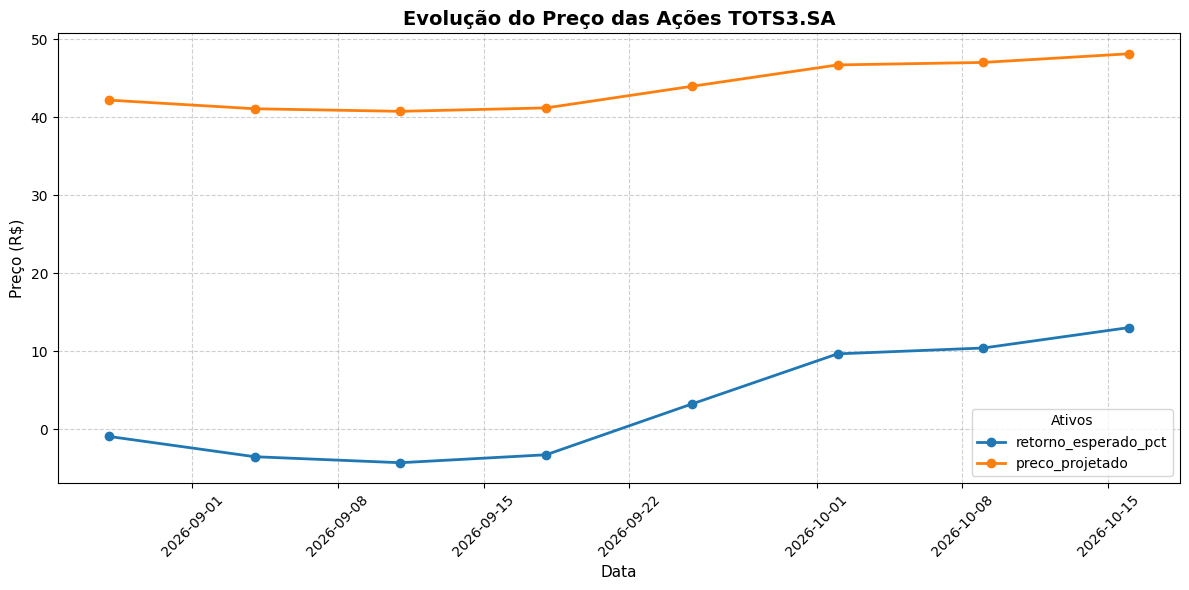

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Exemplo de dados:
#              PETR4   VALE3   ITUB4
# Date
# 2026-01-02   38.50   61.20   34.10
# 2026-01-09   39.10   60.80   34.50

i=6

df_teste = pd.DataFrame([l for l in lista_dfs[3]['projecoes']])

# Garantir formato datetime se necessário
df_teste.index = pd.to_datetime(df_teste.data_alvo)

colunas = ["retorno_esperado_pct", "preco_projetado"]

plt.figure(figsize=(12, 6))

# Plota todas as colunas numéricas de uma vez
for coluna in colunas:
    plt.plot(df_teste.index, df_teste[coluna], marker='o', label=coluna, linewidth=2)

plt.title(f'Evolução do Preço das Ações {acoes_sa[i]}', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=11)
plt.ylabel('Preço (R$)', fontsize=11)
plt.legend(title='Ativos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [70]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

# Fixar sementes para reproducibilidade
torch.manual_seed(42)
np.random.seed(42)


# ==========================================
# 1. Dataset com Janela Deslizante (3D Tensor)
# ==========================================
class StockSequenceDataset(Dataset):

    def __init__(self, X, y, weights=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
        self.weights = (
            torch.tensor(weights, dtype=torch.float32).unsqueeze(-1)
            if weights is not None
            else torch.ones_like(self.y)
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.weights[idx]


def criar_sequencias(features, targets, seq_length=20, half_life=60, base_idx=0):
    """Gera janelas 3D (amostras, seq_length, n_features) e calcula pesos temporais."""
    X_seq, y_seq, weights = [], [], []
    num_amostras = len(features) - seq_length

    # Decaimento exponencial de pesos com base no tempo absoluto
    decay = np.log(2) / half_life

    for i in range(num_amostras):
        X_seq.append(features[i : i + seq_length])
        y_seq.append(targets[i + seq_length])

        # Amostras mais à frente no tempo recebem peso maior
        tempo_passado = (num_amostras - 1) - i
        w = np.exp(-decay * tempo_passado)
        weights.append(w)

    return np.array(X_seq), np.array(y_seq), np.array(weights)


# ==========================================
# 2. Arquitetura do Modelo LSTM
# ==========================================
class StockLSTM(nn.Module):

    def __init__(
        self, input_size, hidden_size=32, num_layers=2, dropout_prob=0.2
    ):
        super(StockLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Camada LSTM Recorrente
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,  # Entrada: (batch, seq_len, features)
            dropout=dropout_prob if num_layers > 1 else 0.0,
        )

        # Dropout e Cabeça Regressora
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(16, 1),  # Saída: Retorno Percentual Contínuo
        )

    def forward(self, x):
        # out: (batch, seq_len, hidden_size)
        out, (h_n, c_n) = self.lstm(x)

        # Seleciona o estado oculto do último passo temporal da sequência
        last_step_out = out[:, -1, :]

        # Projeção densa
        prediction = self.fc(self.dropout(last_step_out))
        return prediction


# ==========================================
# 3. Função de Perda Ponderada (Weighted MSE)
# ==========================================
class WeightedMSELoss(nn.Module):

    def __init__(self):
        super(WeightedMSELoss, self).__init__()

    def forward(self, pred, target, weights):
        loss = weights * (pred - target) ** 2
        return torch.mean(loss)


# ==========================================
# 4. Pipeline de Treinamento e Inferência
# ==========================================
def treinar_modelo_lstm(
    df_diario,
    acao,
    seq_length=20,
    horizonte_dias=5,
    epochs=100,
    lr=0.001,
    batch_size=32,
):
    df = df_diario.copy()

    # Engenharia de Features Estacionárias
    df['Retorno_1D'] = df['Close'].pct_change(1)
    df['Retorno_5D'] = df['Close'].pct_change(5)
    df['Volatilidade_10D'] = df['Retorno_1D'].rolling(10).std()

    sma_curta = df['Close'].rolling(9).mean()
    sma_longa = df['Close'].rolling(21).mean()
    df['Dist_SMA_Ratio'] = (sma_curta - sma_longa) / sma_longa

    # Target: Retorno percentual futuro no horizonte h
    target_col = f'Target_Retorno_{horizonte_dias}D'
    df[target_col] = (
        df['Close'].shift(-horizonte_dias) - df['Close']
    ) / df['Close']

    feature_cols = [
        'Retorno_1D',
        'Retorno_5D',
        'Volatilidade_10D',
        'Dist_SMA_Ratio',
    ]
    df_clean = df.dropna(subset=feature_cols + [target_col])

    # Split Temporal (80% Treino, 20% Validação)
    split_idx = int(len(df_clean) * 0.8)
    df_train = df_clean.iloc[:split_idx]
    df_val = df_clean.iloc[split_idx:]

    # Normalização ajustada apenas no Treino
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(df_train[feature_cols])
    X_val_scaled = scaler.transform(df_val[feature_cols])

    y_train = df_train[target_col].values
    y_val = df_val[target_col].values

    # Geração dos Tensores 3D com janelas de 'seq_length' dias
    X_tr_seq, y_tr_seq, w_tr = criar_sequencias(
        X_train_scaled, y_train, seq_length=seq_length, half_life=40
    )
    X_va_seq, y_va_seq, _ = criar_sequencias(
        X_val_scaled, y_val, seq_length=seq_length, half_life=40
    )

    train_loader = DataLoader(
        StockSequenceDataset(X_tr_seq, y_tr_seq, w_tr),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        StockSequenceDataset(X_va_seq, y_va_seq),
        batch_size=batch_size,
        shuffle=False,
    )

    # Inicialização do Modelo, Otimizador e Loss
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    #print(f"Device: {device}")
    model = StockLSTM(
        input_size=len(feature_cols),
        hidden_size=24,
        num_layers=2,
        dropout_prob=0.2,
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = WeightedMSELoss()

    best_val_loss = float('inf')
    best_weights = None

    # Loop de Treinamento
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch_x, batch_y, batch_w in train_loader:
            batch_x, batch_y, batch_w = (
                batch_x.to(device),
                batch_y.to(device),
                batch_w.to(device),
            )

            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y, batch_w)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * len(batch_x)

        # Validação
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y, _ in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                preds = model(batch_x)
                val_loss = torch.mean((preds - batch_y) ** 2)
                total_val_loss += val_loss.item() * len(batch_x)

        avg_val_loss = total_val_loss / len(X_va_seq)

        # Salva o melhor modelo (Early Stopping checkpoint)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights = model.state_dict().copy()

    # Carregar melhores pesos
    if best_weights is not None:
        model.load_state_dict(best_weights)

    # Inferência para o último ponto histórico
    model.eval()
    with torch.no_grad():
        ultimas_features = df_clean[feature_cols].iloc[-seq_length:].values
        ultimas_features_scaled = scaler.transform(ultimas_features)
        tensor_inferencia = (
            torch.tensor(ultimas_features_scaled, dtype=torch.float32)
            .unsqueeze(0)
            .to(device)
        )

        retorno_projetado = float(model(tensor_inferencia).cpu().numpy()[0, 0])
        ultimo_preco = float(df_clean['Close'].iloc[-1])
        preco_projetado = ultimo_preco * (1 + retorno_projetado)

    return {
        'acao': acao,
        'horizonte_dias': horizonte_dias,
        'retorno_projetado_pct': round(retorno_projetado * 100, 2),
        'preco_projetado': round(preco_projetado, 2),
        'melhor_mse_validacao': round(best_val_loss, 6),
    }

def coletar_info_stocks(ticker: str) -> pd.DataFrame:
    stock = yf.Ticker(ticker)
    end_date = datetime.now()
    # B3 opera ~21 dias de trading/mês, adiciona buffer para alinhamento exato
    meses = 18
    start_days = int(meses * 30) 
    start_date = (end_date - timedelta(days=start_days)).strftime('%Y-%m-%d')
    print(f"Conta: end date: {end_date} - dias: ({timedelta(days=start_days)})")
    print(f"Start Date: {start_date}")


    df = stock.history(period='max', auto_adjust=True, start=start_date).copy()
    # Remove linhas com preço nulo e garante ordem cronológica
    #df = df[~df['Close'].isna()].sort_index().reset_index(drop=True)
    df = df[~df['Close'].isna()].sort_index()

    return df


In [76]:
acoes = ["ITUB4","ANIM3","BBSE3","PETR4","EMBJ3","GGBR4","TOTS3"]

acoes = [acao+".SA" for acao in acoes]

for acao in acoes:
    df = coletar_info_stocks(acao)
    print(treinar_modelo_lstm(df, acao, horizonte_dias=21))

Conta: end date: 2026-08-18 21:12:10.786663 - dias: (540 days, 0:00:00)
Start Date: 2025-02-24


c:\agy2-projects\meu-agente-cli\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'acao': 'ITUB4.SA', 'horizonte_dias': 21, 'retorno_projetado_pct': -0.1, 'preco_projetado': 42.24, 'melhor_mse_validacao': 0.003168}
Conta: end date: 2026-08-18 21:12:14.051638 - dias: (540 days, 0:00:00)
Start Date: 2025-02-24


c:\agy2-projects\meu-agente-cli\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'acao': 'ANIM3.SA', 'horizonte_dias': 21, 'retorno_projetado_pct': 22.26, 'preco_projetado': 2.67, 'melhor_mse_validacao': 0.02936}
Conta: end date: 2026-08-18 21:12:16.878208 - dias: (540 days, 0:00:00)
Start Date: 2025-02-24


...

c:\agy2-projects\meu-agente-cli\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'acao': 'EMBJ3.SA', 'horizonte_dias': 21, 'retorno_projetado_pct': -0.1, 'preco_projetado': 83.21, 'melhor_mse_validacao': 0.014478}
Conta: end date: 2026-08-18 21:12:24.738717 - dias: (540 days, 0:00:00)
Start Date: 2025-02-24


c:\agy2-projects\meu-agente-cli\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'acao': 'GGBR4.SA', 'horizonte_dias': 21, 'retorno_projetado_pct': 5.1, 'preco_projetado': 24.82, 'melhor_mse_validacao': 0.006601}
Conta: end date: 2026-08-18 21:12:27.418234 - dias: (540 days, 0:00:00)
Start Date: 2025-02-24
{'acao': 'TOTS3.SA', 'horizonte_dias': 21, 'retorno_projetado_pct': -1.13, 'preco_projetado': 28.5, 'melhor_mse_validacao': 0.007819}


c:\agy2-projects\meu-agente-cli\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
